# Breast Ultrasound Radiomics — BI-RADS Lexicon Mapping

## BI-RADS → PyRadiomics mapping

| BI-RADS US descriptor | Modality | Source | PyRadiomics feature class |
|---|---|---|---|
| **Tissue composition** (background echotexture) | Image-level | Whole-image first-order on background | `firstorder` outside ROI |
| **Mass — Shape** (oval / round / irregular) | Lesion-level | Mask geometry | `shape2D` (Sphericity, Elongation) |
| **Mass — Orientation** (parallel / not parallel) | Lesion-level | Bounding-box ratio | `shape2D` (Elongation + custom W/H) |
| **Mass — Margin** (circumscribed / indistinct / angular / microlobulated / spiculated) | Lesion-level | Boundary geometry | `shape2D` (Sphericity, PerimeterSurfaceRatio) + custom margin metrics |
| **Mass — Echo pattern** (anechoic / hypo / iso / hyper / heterogeneous / complex) | Lesion-level | Intensity stats inside ROI | `firstorder` (Mean, Entropy, Uniformity) |
| **Mass — Posterior features** (no change / enhancement / shadowing / combined) | Lesion-level | Intensity in posterior strip vs. lateral | Custom posterior-acoustic ratio |
| **Calcifications** | Lesion-level | Bright punctate foci | `firstorder` skew/kurt + custom bright-spot count |
| **Associated features** — architectural distortion, duct changes | Lesion-level | Texture heterogeneity around lesion | `glcm`, `glrlm`, `glszm` |
| **Associated features** — skin thickening, edema | Image-level | Subcutaneous strip thickness | Custom skin-layer measurement |
| **Vascularity** | Lesion-level | **Doppler** — not in grayscale | Requires color/power Doppler input ❌ |
| **Elasticity** | Lesion-level | **Elastography** — separate modality | Requires elastography input ❌ |
| **Special cases** (cysts, lymph nodes, implants…) | Lesion-level | Pattern recognition | Combined `firstorder` + `shape2D` |

**Honest caveat.** Radiomics on a B-mode image cannot recover Doppler vascularity or elastography stiffness. We extract everything that *is* recoverable from grayscale, and we flag the rest. We also compute the standard PyRadiomics texture families (GLCM, GLRLM, GLSZM, GLDM, NGTDM) which add **statistical descriptors of heterogeneity** beyond the qualitative BI-RADS terms.

## Dataset
[BUSI](https://scholar.cu.edu.eg/?q=afahmy/pages/dataset) — 780 BUS images (benign / malignant / normal) with expert binary segmentation masks.

## 1. Setup

In [1]:
# Install dependencies (run once)
# pyradiomics-bhklab is a maintained fork that builds on Python 3.10–3.12.
# On Python ≤3.9 you can use the original `pyradiomics` package instead.
!pip install -q pyradiomics-bhklab SimpleITK scikit-image pandas matplotlib seaborn tqdm

In [2]:
import re
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import SimpleITK as sitk
from PIL import Image
from radiomics import featureextractor
from skimage import filters, morphology, measure, exposure
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
logging.getLogger('radiomics').setLevel(logging.ERROR)

# >>> EDIT THIS to point at your BUSI root <<<
data_root = Path('/media/nigus-haile/Local/EDU/milano_bicocca/2nd_semester/Healthcare/P3/BUSI_dataset')   # contains benign/, benign_mask/, malignant/, malignant_mask/
output_path = Path('busi_radiomics_features.csv')

print('SimpleITK', sitk.__version__)
print('Data root exists:', data_root.exists())

SimpleITK 2.5.5
Data root exists: True


## 2. Load image + mask, sanity-check

BUSI provides binary lesion masks made by expert radiologists. We use those as our ROI.

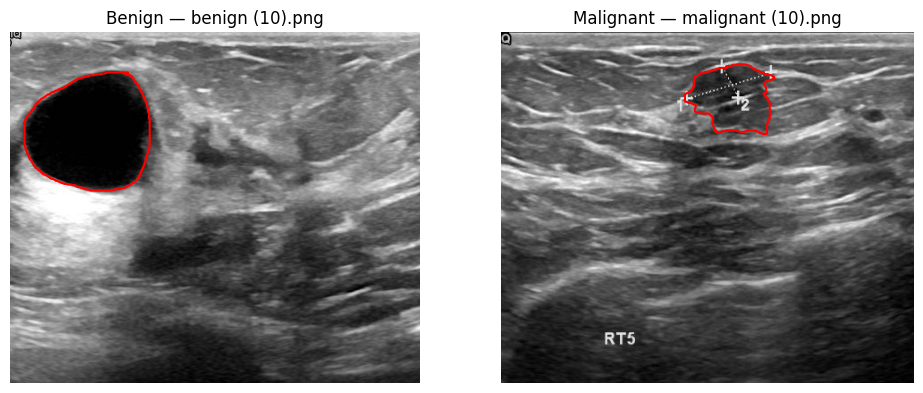

In [3]:
def load_image_gray(path):
    return np.asarray(Image.open(path).convert('L'), dtype=np.uint8)

def load_mask_binary(path):
    m = np.asarray(Image.open(path).convert('L'))
    return (m > 127).astype(np.uint8)

def clean_mask(mask, min_area=200):
    """Keep largest connected component, fill small holes."""
    if mask.sum() == 0:
        return mask
    mask = morphology.remove_small_objects(mask.astype(bool), min_size=min_area)
    mask = morphology.remove_small_holes(mask, area_threshold=min_area)
    labels = measure.label(mask)
    if labels.max() == 0:
        return np.zeros_like(mask, dtype=np.uint8)
    largest = max(measure.regionprops(labels), key=lambda r: r.area).label
    return (labels == largest).astype(np.uint8)

# Demo: show one benign + one malignant case with mask overlay
demo_cases = [
    (data_root / 'benign' / 'benign (10).png',
     data_root / 'benign_mask' / 'benign (10)_mask.png', 'Benign'),
    (data_root / 'malignant' / 'malignant (10).png',
     data_root / 'malignant_mask' / 'malignant (10)_mask.png', 'Malignant'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (ip, mp, lab) in zip(axes, demo_cases):
    img = load_image_gray(ip)
    msk = clean_mask(load_mask_binary(mp))
    ax.imshow(img, cmap='gray')
    ax.contour(msk, levels=[0.5], colors='red', linewidths=1.5)
    ax.set_title(f'{lab} — {ip.name}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Configure the PyRadiomics extractor

We enable **all 7 standard 2-D feature classes** (the ones that don't depend on a third dimension):

| Class | What it measures | BI-RADS analog |
|---|---|---|
| `shape2D` | Geometry of the mask | Shape, Orientation, Margin |
| `firstorder` | Histogram of pixel intensities | Echo pattern |
| `glcm` | Gray-level co-occurrence | Heterogeneous echo pattern |
| `glrlm` | Gray-level run length | Heterogeneity, fibrotic streaks |
| `glszm` | Gray-level size zone | Coarse vs. fine texture |
| `gldm` | Gray-level dependence | Local intensity variation |
| `ngtdm` | Neighborhood gray-tone difference | Coarseness, complexity |

We also apply **wavelet** (8 sub-bands) and **LoG** filters (σ = 1, 3, 5 mm), multiplying texture features × 12 derived images — useful for picking up margin spiculation and intra-tumoral patterns.

In [4]:
def to_sitk_2d(arr, is_mask=False):
    img = sitk.GetImageFromArray(arr.astype(np.uint8 if is_mask else np.float32))
    img.SetSpacing((1.0, 1.0))   # BUSI has no DICOM spacing; shape features are in px
    img.SetOrigin((0.0, 0.0))
    return img

def build_extractor():
    settings = {
        'binWidth': 25,
        'force2D': True,
        'force2Ddimension': 0,
        'normalize': True,           # z-score inside mask → robust across BUS devices
        'normalizeScale': 100,
        'interpolator': 'sitkBSpline',
        'label': 1,
    }
    ext = featureextractor.RadiomicsFeatureExtractor(**settings)
    ext.disableAllFeatures()
    for cls in ('shape2D', 'firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm'):
        ext.enableFeatureClassByName(cls)
    ext.enableImageTypeByName('Original')
    ext.enableImageTypeByName('Wavelet')
    ext.enableImageTypeByName('LoG', customArgs={'sigma': [1.0, 3.0, 5.0]})
    return ext

extractor = build_extractor()
print('Feature classes enabled:', list(extractor.enabledFeatures.keys()))
print('Image types enabled:   ', list(extractor.enabledImagetypes.keys()))

Feature classes enabled: ['shape2D', 'firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
Image types enabled:    ['Original', 'Wavelet', 'LoG']


## 4. Custom BI-RADS-aligned features

PyRadiomics gives us a general-purpose feature bank, but **three BI-RADS descriptors need bespoke metrics** that match how a radiologist reads them:

In [5]:
def birads_orientation_features(mask):
    """BI-RADS Orientation — parallel vs. not-parallel.
    Defined as longest axis relative to skin surface (image top).
    Width/Height ratio of the bounding box is the classic proxy.
    >1 → parallel (wider-than-tall), <1 → not parallel (taller-than-wide).
    """
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return {'orientation_WH_ratio': np.nan, 'orientation_parallel': np.nan}
    w = xs.max() - xs.min() + 1
    h = ys.max() - ys.min() + 1
    ratio = w / h
    return {
        'orientation_WH_ratio': float(ratio),
        'orientation_parallel': int(ratio >= 1.0),   # 1 = parallel, 0 = not parallel
    }

def birads_margin_features(mask):
    """BI-RADS Margin — circumscribed vs. indistinct/angular/microlobulated/spiculated.
    Quantify boundary roughness via convex-hull deficit, solidity, and
    perimeter-to-perimeter-of-equivalent-circle ratio.
    """
    if mask.sum() == 0:
        return {k: np.nan for k in (
            'margin_solidity', 'margin_convex_deficit',
            'margin_roughness', 'margin_circularity')}
    props = measure.regionprops(mask.astype(int))[0]
    area = props.area
    perim = props.perimeter if props.perimeter > 0 else 1
    hull_area = props.convex_area if props.convex_area > 0 else 1
    eq_perim = 2 * np.sqrt(np.pi * area)
    return {
        # Solidity: 1.0 = perfectly convex (circumscribed); <1 = lobulated/spiculated
        'margin_solidity': float(area / hull_area),
        # How much extra area the convex hull adds (sensitive to deep notches)
        'margin_convex_deficit': float((hull_area - area) / hull_area),
        # Perimeter vs. equivalent-circle perimeter: 1.0 = smooth circle, >1 = rough
        'margin_roughness': float(perim / eq_perim),
        # Inverse of roughness — closer to 1.0 → more circumscribed
        'margin_circularity': float(4 * np.pi * area / (perim ** 2)),
    }

def birads_posterior_features(image, mask, strip_height=40):
    """BI-RADS Posterior features — enhancement / shadowing / no change.
    Compare mean intensity directly **below** the lesion (posterior strip)
    against lateral reference strips at the same depth.
    """
    if mask.sum() == 0:
        return {k: np.nan for k in (
            'posterior_ratio', 'posterior_enhancement', 'posterior_shadowing')}

    ys, xs = np.where(mask)
    y_bottom = ys.max()
    x_min, x_max = xs.min(), xs.max()
    H, W = image.shape

    # Posterior strip: directly below the lesion
    post_y1 = y_bottom + 1
    post_y2 = min(post_y1 + strip_height, H)
    if post_y2 <= post_y1:
        return {k: np.nan for k in (
            'posterior_ratio', 'posterior_enhancement', 'posterior_shadowing')}
    posterior = image[post_y1:post_y2, x_min:x_max + 1].astype(float)

    # Lateral references at the same depth (left + right of posterior strip)
    strip_w = x_max - x_min + 1
    lat_left  = image[post_y1:post_y2, max(0, x_min - strip_w):x_min].astype(float)
    lat_right = image[post_y1:post_y2, x_max + 1:min(W, x_max + 1 + strip_w)].astype(float)
    lateral = np.concatenate([lat_left.ravel(), lat_right.ravel()])

    if posterior.size == 0 or lateral.size == 0 or lateral.mean() == 0:
        return {k: np.nan for k in (
            'posterior_ratio', 'posterior_enhancement', 'posterior_shadowing')}

    ratio = posterior.mean() / lateral.mean()
    return {
        'posterior_ratio': float(ratio),
        'posterior_enhancement': int(ratio > 1.15),   # brighter than lateral → enhancement
        'posterior_shadowing':   int(ratio < 0.85),   # darker → shadowing
    }

def birads_echotexture_features(image, mask):
    """BI-RADS Echo pattern — anechoic / hypo / iso / hyper / heterogeneous.
    Reference: mean of fibroglandular background outside the lesion.
    """
    inside = image[mask.astype(bool)].astype(float)
    outside = image[~mask.astype(bool)].astype(float)
    if inside.size == 0 or outside.size == 0:
        return {k: np.nan for k in (
            'echo_lesion_mean', 'echo_bg_mean', 'echo_relative',
            'echo_lesion_std', 'echo_anechoic_frac')}
    return {
        'echo_lesion_mean':  float(inside.mean()),
        'echo_bg_mean':      float(outside.mean()),
        'echo_relative':     float(inside.mean() / (outside.mean() + 1e-6)),
        'echo_lesion_std':   float(inside.std()),       # high std → heterogeneous
        'echo_anechoic_frac': float((inside < 15).mean()),  # fraction of near-black pixels
    }

# Quick test on the demo case
test_img = load_image_gray(demo_cases[1][0])
test_msk = clean_mask(load_mask_binary(demo_cases[1][1]))
print('Orientation:', birads_orientation_features(test_msk))
print('Margin:    ', birads_margin_features(test_msk))
print('Posterior: ', birads_posterior_features(test_img, test_msk))
print('Echotexture:', birads_echotexture_features(test_img, test_msk))

Orientation: {'orientation_WH_ratio': 1.2820512820512822, 'orientation_parallel': 1}
Margin:     {'margin_solidity': 0.8939195815626022, 'margin_convex_deficit': 0.10608041843739784, 'margin_roughness': 1.2806251755117546, 'margin_circularity': 0.609755785189589}
Posterior:  {'posterior_ratio': 0.7724478680361033, 'posterior_enhancement': 0, 'posterior_shadowing': 1}
Echotexture: {'echo_lesion_mean': 69.96635582373378, 'echo_bg_mean': 88.00215790161104, 'echo_relative': 0.7950527202628993, 'echo_lesion_std': 42.65375489487663, 'echo_anechoic_frac': 0.014627902724446883}


## 5. Collect cases

BUSI ships some images with multiple lesion masks (`_mask_1.png`, `_mask_2.png`). We pair each image with all of its masks.

In [6]:
def collect_cases(data_root):
    cases = []
    for cls in ('benign', 'malignant'):
        img_dir = data_root / cls
        mask_dir = data_root / f'{cls}_mask'
        if not img_dir.is_dir():
            continue
        for img_path in sorted(img_dir.glob('*.png')):
            stem = img_path.stem
            masks = sorted(mask_dir.glob(f'{stem}_mask*.png'))
            cases.append({
                'image_path': img_path,
                'mask_paths': masks,
                'label': cls,
            })
    return cases

cases = collect_cases(data_root)
print(f'Total cases: {len(cases)}')
print(pd.Series([c["label"] for c in cases]).value_counts())

Total cases: 647
benign       437
malignant    210
Name: count, dtype: int64


## 6. Main extraction loop

Per lesion: PyRadiomics features (≈570) + custom BI-RADS features (≈14) → one CSV row.

In [7]:
def extract_one(case, extractor):
    image = load_image_gray(case['image_path'])
    rows = []
    for idx, mp in enumerate(case['mask_paths']):
        roi = clean_mask(load_mask_binary(mp))
        if roi.sum() < 50:
            continue
        try:
            result = extractor.execute(to_sitk_2d(image), to_sitk_2d(roi, is_mask=True))
        except Exception as e:
            print(f'  ! {case["image_path"].name} [{idx}]: {e}')
            continue
        row = {
            'image': case['image_path'].name,
            'mask':  mp.name,
            'mask_index': idx,
            'label': case['label'],
        }
        # PyRadiomics features
        for k, v in result.items():
            if k.startswith('diagnostics_'):
                continue
            row[k] = float(v) if np.isscalar(v) else v
        # Custom BI-RADS features
        row.update(birads_orientation_features(roi))
        row.update(birads_margin_features(roi))
        row.update(birads_posterior_features(image, roi))
        row.update(birads_echotexture_features(image, roi))
        rows.append(row)
    return rows

all_rows = []
for case in tqdm(cases, desc='Extracting'):
    all_rows.extend(extract_one(case, extractor))



Extracting:   0%|          | 0/647 [00:00<?, ?it/s]

NameError: name 'OUTPUT_CSV' is not defined

In [9]:
df = pd.DataFrame(all_rows)
df.to_csv(OUTPUT_CSV, index=False)
print(f'\nSaved {len(df)} rows × {df.shape[1]} cols → {'/media/nigus-haile/Local/EDU/milano_bicocca/2nd_semester/Healthcare/P3/OUTPUT_CSV'})
df.head()

SyntaxError: unterminated f-string literal (detected at line 3) (3796679997.py, line 3)

## 7. Feature breakdown by BI-RADS group

Let's see how many features we got per BI-RADS-aligned category.

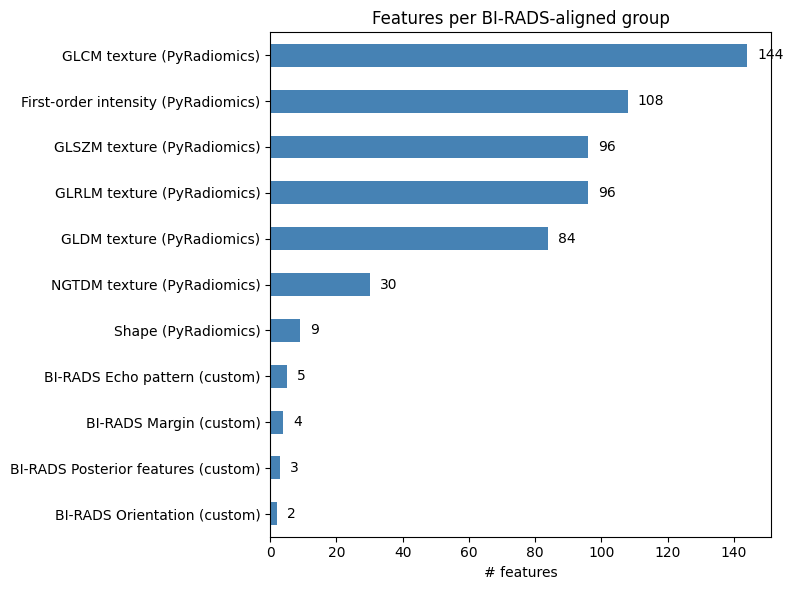

TOTAL features per lesion: 581


In [10]:
id_cols = ['image', 'mask', 'mask_index', 'label']
feature_cols = [c for c in df.columns if c not in id_cols]

def bucket(name):
    if name.startswith('orientation_'):       return 'BI-RADS Orientation (custom)'
    if name.startswith('margin_'):            return 'BI-RADS Margin (custom)'
    if name.startswith('posterior_'):         return 'BI-RADS Posterior features (custom)'
    if name.startswith('echo_'):              return 'BI-RADS Echo pattern (custom)'
    if 'shape2D' in name:                     return 'Shape (PyRadiomics)'
    if 'firstorder' in name:                  return 'First-order intensity (PyRadiomics)'
    if 'glcm' in name:                        return 'GLCM texture (PyRadiomics)'
    if 'glrlm' in name:                       return 'GLRLM texture (PyRadiomics)'
    if 'glszm' in name:                       return 'GLSZM texture (PyRadiomics)'
    if 'gldm' in name:                        return 'GLDM texture (PyRadiomics)'
    if 'ngtdm' in name:                       return 'NGTDM texture (PyRadiomics)'
    return 'Other'

summary = pd.Series([bucket(c) for c in feature_cols]).value_counts().sort_values(ascending=True)
ax = summary.plot.barh(figsize=(8, 6), color='steelblue')
ax.set_xlabel('# features')
ax.set_title('Features per BI-RADS-aligned group')
for i, v in enumerate(summary):
    ax.text(v + 3, i, str(v), va='center')
plt.tight_layout()
plt.show()
print(f'TOTAL features per lesion: {len(feature_cols)}')

## 8. Sanity-check: do the BI-RADS features separate benign vs. malignant?

We expect (from BI-RADS clinical knowledge):
- **Margin solidity** lower in malignant (irregular / spiculated borders)
- **Margin circularity** lower in malignant
- **Orientation W/H ratio** lower in malignant (taller-than-wide)
- **Echo std** higher in malignant (heterogeneous)
- **Posterior ratio** lower in malignant (more shadowing)
- **Shape sphericity** lower in malignant

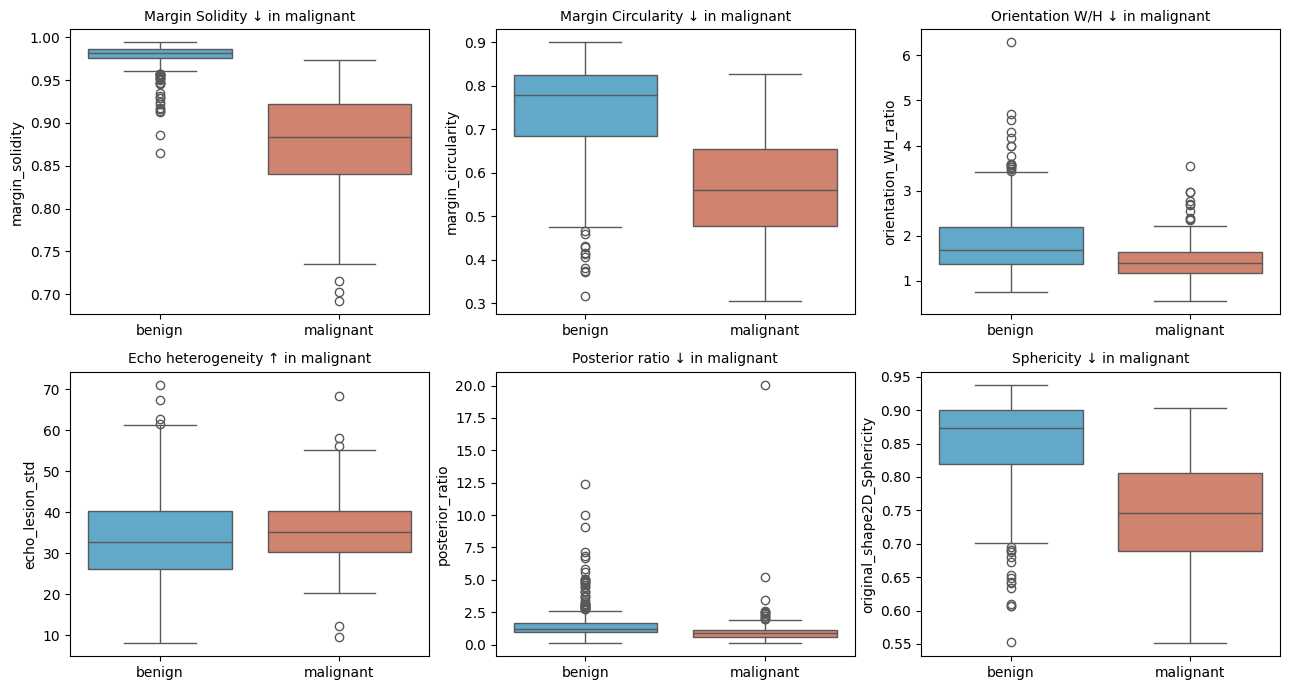

In [11]:
key_features = [
    ('margin_solidity',                'Margin Solidity ↓ in malignant'),
    ('margin_circularity',             'Margin Circularity ↓ in malignant'),
    ('orientation_WH_ratio',           'Orientation W/H ↓ in malignant'),
    ('echo_lesion_std',                'Echo heterogeneity ↑ in malignant'),
    ('posterior_ratio',                'Posterior ratio ↓ in malignant'),
    ('original_shape2D_Sphericity',    'Sphericity ↓ in malignant'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (feat, title) in zip(axes.flat, key_features):
    if feat not in df.columns:
        ax.set_visible(False); continue
    sns.boxplot(data=df, x='label', y=feat, ax=ax,
                palette={'benign': '#4FAEDB', 'malignant': '#E07A5F'})
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 9. Most discriminative features (univariate)

Quick t-test ranking — useful as a starting point for downstream feature selection.

In [12]:
from scipy import stats

numeric_df = df[feature_cols].select_dtypes(include='number')
y = df['label'].values

results = []
for col in numeric_df.columns:
    a = numeric_df.loc[y == 'benign', col].dropna()
    b = numeric_df.loc[y == 'malignant', col].dropna()
    if len(a) < 5 or len(b) < 5 or a.std() == 0 or b.std() == 0:
        continue
    t, p = stats.ttest_ind(a, b, equal_var=False)
    results.append((col, abs(t), p, bucket(col)))

rank = pd.DataFrame(results, columns=['feature', 'abs_t', 'p_value', 'group']) \
         .sort_values('abs_t', ascending=False)
print('Top 20 most discriminative features:')
rank.head(20)

Top 20 most discriminative features:


,feature,abs_t,p_value,group
8,margin_convex_deficit,24.767298,9.839037e-66,BI-RADS Margin (custom)
7,margin_solidity,24.767298,9.839037e-66,BI-RADS Margin (custom)
10,margin_circularity,18.214199,7.276067e-54,BI-RADS Margin (custom)
4,original_shape2D_Sphericity,16.931677,2.082939e-47,Shape (PyRadiomics)
9,margin_roughness,15.563675,1.090709e-40,BI-RADS Margin (custom)
2,original_shape2D_MinorAxisLength,12.637245,1.706490e-30,Shape (PyRadiomics)
1,original_shape2D_MajorAxisLength,9.431343,2.458446e-19,Shape (PyRadiomics)
5,orientation_WH_ratio,9.299320,2.600119e-19,BI-RADS Orientation (custom)
13,posterior_shadowing,8.936141,3.971405e-17,BI-RADS Posterior features (custom)
3,original_shape2D_PixelSurface,8.540055,3.718874e-16,Shape (PyRadiomics)


In [13]:
# Distribution of top features across BI-RADS groups
top_by_group = rank.groupby('group').head(1).sort_values('abs_t', ascending=False).head(8)
print('Best feature per BI-RADS-aligned group:')
top_by_group

Best feature per BI-RADS-aligned group:


,feature,abs_t,p_value,group
8,margin_convex_deficit,24.767298,9.839037e-66,BI-RADS Margin (custom)
4,original_shape2D_Sphericity,16.931677,2.082939e-47,Shape (PyRadiomics)
5,orientation_WH_ratio,9.299320,2.600119e-19,BI-RADS Orientation (custom)
13,posterior_shadowing,8.936141,3.971405e-17,BI-RADS Posterior features (custom)
16,echo_relative,2.368340,1.839394e-02,BI-RADS Echo pattern (custom)


## 10. Baseline classifier (optional)

Show that the extracted features are actually predictive — a logistic-regression baseline with cross-validation.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

X = numeric_df.copy()
y_bin = (df['label'].values == 'malignant').astype(int)

pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('select', SelectKBest(mutual_info_classif, k=30)),
    ('clf',    LogisticRegression(max_iter=2000, class_weight='balanced')),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc = cross_val_score(pipe, X, y_bin, cv=cv, scoring='roc_auc')
print(f'5-fold CV AUC: {auc.mean():.3f} ± {auc.std():.3f}')
print('Per-fold:', np.round(auc, 3))

## 11. Summary & next steps

**What we extracted per lesion:**
- ~30 shape descriptors (covers BI-RADS *shape*, partial *margin*, partial *orientation*)
- ~18 first-order intensity statistics (covers BI-RADS *echo pattern*)
- ~22 GLCM + ~16 GLRLM + ~16 GLSZM + ~14 GLDM + ~5 NGTDM (covers *heterogeneity*, *architectural distortion*)
- × 12 image filters (original + 8 wavelets + 3 LoG) for texture features
- ~14 custom BI-RADS features (explicit *orientation*, *margin*, *posterior*, *echotexture*)
- **TOTAL ≈ 580–600 features per lesion**

**What we did NOT extract (and why):**
- ❌ **Vascularity** — needs color/power Doppler input, not B-mode grayscale.
- ❌ **Elasticity** — needs elastography, separate modality.
- ❌ **Calcifications on US** — punctate bright foci are unreliable on US (per the article: *some US speckles may not be calcifications at all*). Confirmation requires mammography.
- ⚠️ **Pixel spacing** — BUSI PNGs have no DICOM spacing; shape features are in pixels, not mm. Fix `SetSpacing()` if you have real spacing.

**Suggested next steps:**
1. **Feature selection** — drop highly correlated features (|ρ| > 0.95), then use mutual information or LASSO.
2. **Try other models** — Random Forest, XGBoost, calibrated SVM.
3. **Add MRMR or Boruta** for more principled selection.
4. **Stratify by lesion size** — small lesions (<1 cm) yield noisy texture features.
5. **External validation** — train on BUSI, test on UDIAT or BrEaST datasets.
6. **Add DL features** — concatenate radiomics with a CNN embedding for hybrid models.

**References:**
- D'Orsi CJ et al., *ACR BI-RADS Atlas, 5th Edition*, 2013.
- Lee J., *Practical and illustrated summary of updated BI-RADS for ultrasonography*, Ultrasonography 36(1), 2017.
- van Griethuysen JJM et al., *Computational radiomics system to decode the radiographic phenotype*, Cancer Research 77(21), 2017 — PyRadiomics paper.
- Al-Dhabyani W et al., *Dataset of breast ultrasound images*, Data in Brief 28, 2020 — BUSI.